# Import PyTorch

In [1]:
import torch
import numpy as np

In [2]:
torch.__version__

'2.10.0+cu128'

## Tensor

### Create tensor

In [3]:
x = torch.tensor(7)
x

tensor(7)

In [4]:
x.data, x.ndim, x.shape, x.item()

(tensor(7), 0, torch.Size([]), 7)

- `data` to get tensor data
- `ndim` to get tensor dimension number. eg 0 for scalar, 1 for vector, 2 for 2d matix...
- `shape` to get the shape of your tensor
- `item` for the value inside your tensor (only for tensor of ndim==0)

In [5]:
torch.tensor(np.random.randint(0,100,(24,24,3))).shape

torch.Size([24, 24, 3])

You can also specify the type of data inside the tensor

In [6]:
torch.tensor(np.random.randint(0,10,(3,3,3)), dtype=torch.int)

tensor([[[5, 4, 3],
         [1, 5, 5],
         [0, 5, 7]],

        [[3, 3, 4],
         [8, 6, 2],
         [1, 7, 9]],

        [[8, 9, 5],
         [3, 6, 9],
         [3, 4, 8]]], dtype=torch.int32)

In [7]:
TENSOR = torch.tensor([[[1, 2, 3],
                        [3, 6, 9],
                        [2, 4, 5]],
                        [[4, 9, 2],
                        [8, 2, 8],
                        [6, 9, 1]]], dtype=torch.float)

In [8]:
TENSOR.shape, TENSOR.ndim, TENSOR.var(dim=2), TENSOR.mean(dim=2), TENSOR.median(dim=2)

(torch.Size([2, 3, 3]),
 3,
 tensor([[ 1.0000,  9.0000,  2.3333],
         [13.0000, 12.0000, 16.3333]]),
 tensor([[2.0000, 6.0000, 3.6667],
         [5.0000, 6.0000, 5.3333]]),
 torch.return_types.median(
 values=tensor([[2., 6., 4.],
         [4., 8., 6.]]),
 indices=tensor([[1, 1, 1],
         [0, 0, 0]])))

In [9]:
x = torch.randint(0,100,(1,10), dtype=torch.float).reshape(-1)
x

tensor([33., 38., 67.,  5., 22., 33., 69.,  5., 84., 83.])

In [10]:
print(f"-> Size = {x.size()[0]}")
print(f"-> Min = {x.min()}")
print(f"-> Max = {x.max()}")
print(f"-> Mean = {x.mean():.3f}")
print(f"-> Std = {x.std():.3f}")
print(f"-> ArgMin = {x.argmin()}")
print(f"-> ArgMax = {x.argmax()}")

-> Size = 10
-> Min = 5.0
-> Max = 84.0
-> Mean = 43.900
-> Std = 29.961
-> ArgMin = 3
-> ArgMax = 8


In [11]:
# Default datatype for tensors is float32
float_32_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=None, # defaults to None, which is torch.float32 or whatever datatype is passed
                               device=None, # defaults to None, which uses the default tensor type
                               requires_grad=False) # if True, operations performed on the tensor are recorded 

float_32_tensor.shape, float_32_tensor.dtype, float_32_tensor.device

(torch.Size([3]), torch.float32, device(type='cpu'))

In [12]:
#Expected one of cpu, cuda, ipu, xpu, mkldnn, opengl, opencl, ideep, hip, ve, fpga, maia, xla, lazy, vulkan, mps, meta, hpu, mtia, privateuseone device type at start of device string: gpu
torch.device('cuda')

#You can check if cuda is available using
cuda_available = torch.cuda.is_available()

print(f"CUDA Available: {cuda_available}")

CUDA Available: False


In [13]:
tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=torch.float64,
                               device=torch.device('cpu'),
                               requires_grad=False)

float_32_tensor.shape, float_32_tensor.dtype, float_32_tensor.device

(torch.Size([3]), torch.float32, device(type='cpu'))

### Random tensor

In [14]:
torch.rand((10,5))

tensor([[0.4538, 0.6985, 0.6703, 0.9235, 0.6829],
        [0.3902, 0.7974, 0.1033, 0.9150, 0.7023],
        [0.4332, 0.5168, 0.8150, 0.1171, 0.5243],
        [0.4716, 0.1055, 0.1588, 0.8094, 0.3372],
        [0.0148, 0.0140, 0.7008, 0.4860, 0.0182],
        [0.0930, 0.7983, 0.1885, 0.3468, 0.7812],
        [0.0604, 0.3119, 0.3864, 0.3877, 0.8826],
        [0.0601, 0.5769, 0.6045, 0.8014, 0.5324],
        [0.9048, 0.5267, 0.3762, 0.7300, 0.3066],
        [0.4135, 0.0645, 0.4692, 0.6407, 0.7536]])

In [15]:
random_image = torch.randint(low=0, high=255, size=(25,25,3))

In [16]:
random_image2 = torch.randint_like(random_image, low=0, high=255)

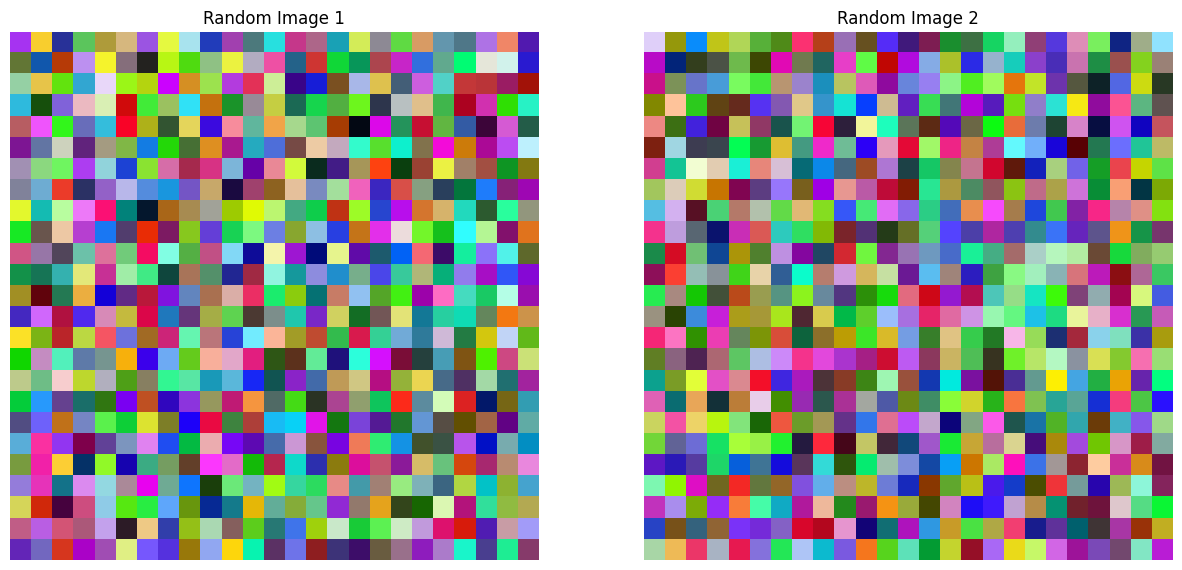

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

plt.subplot(1,2,1)
plt.imshow(random_image)
plt.title("Random Image 1")
plt.axis(False)

plt.subplot(1,2,2)
plt.imshow(random_image2)
plt.title("Random Image 2")
plt.axis(False)

plt.show()

In [18]:
img_shape = (72,72,3)
data = [torch.randint(low=0, high=255, size=img_shape, dtype=torch.float) for i in range(1000)]

tensor_data = torch.stack(data, dim=0)
tensor_data.shape

torch.Size([1000, 72, 72, 3])

In [19]:
torch.reshape(tensor_data, (len(data),-1)).shape, np.prod(data[0].shape)

(torch.Size([1000, 15552]), np.int64(15552))

In [20]:
#A series of values between 0 and 100 (excluded) with a step of 5 between each pair of adjacent points. 
torch.arange(start=0,end=100, step=5)

tensor([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85,
        90, 95])

In [21]:
#A series of 5 values between 0 and 100 (included) with linearly separated points. 
torch.linspace(0, 100, 5)

tensor([  0.,  25.,  50.,  75., 100.])

### Zeros and Ones

In [22]:
torch.zeros((3,3), dtype=torch.int)

tensor([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]], dtype=torch.int32)

In [23]:
torch.ones(3,3, dtype=torch.float32)

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])

In [24]:
torch.eye(3)

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

In [25]:
torch.eye(5,5)

tensor([[1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1.]])

In [26]:
X = torch.randn((1,3))
delta_X=1e-4
I = torch.ones_like(X)*delta_X
(torch.sin(X+I)-torch.sin(X))/delta_X, torch.cos(X)

(tensor([[ 0.7039, -0.0912,  0.1955]]), tensor([[ 0.7043, -0.0914,  0.1956]]))

### Operation on tensor

In [27]:
#The shape should be equal for the sum of 2 vectors
torch.tensor([1,2,3])+10, torch.tensor([1,2,3])+torch.tensor([4,5,6])

(tensor([11, 12, 13]), tensor([5, 7, 9]))

In [28]:
#The shape should be equal for the substraction of 2 vectors
torch.tensor([1,2,3])-10, torch.tensor([1,2,3])-torch.tensor([4,5,6])

(tensor([-9, -8, -7]), tensor([-3, -3, -3]))

In [29]:
#The shape should be equal for the multiplication (element-wise) of 2 vectors
torch.tensor([1,2,3])*10, torch.tensor([1,2,3])*torch.tensor([4,5,6])

(tensor([10, 20, 30]), tensor([ 4, 10, 18]))

Using the torch dedicated function you can end with the same results and the observations above are still applied 

In [30]:
torch.add(torch.tensor([1,2,3]), torch.tensor([4,5,6]))

tensor([5, 7, 9])

In [31]:
torch.add(torch.tensor([1,2,3]), torch.tensor(5))

tensor([6, 7, 8])

In [32]:
torch.sub(torch.tensor([1,2,3]), torch.tensor([4,5,6])), torch.subtract(torch.tensor([1,2,3]), torch.tensor([4,5,6]))

(tensor([-3, -3, -3]), tensor([-3, -3, -3]))

In [33]:
torch.mul(torch.tensor([1,2,3]), torch.tensor([4,5,6])), torch.multiply(torch.tensor([1,2,3]), torch.tensor([4,5,6]))

(tensor([ 4, 10, 18]), tensor([ 4, 10, 18]))

In [34]:
tensor_A = torch.randint(10,(4,3))
tensor_B = torch.randint(10,(3,4))
tensor_A, tensor_B

(tensor([[0, 9, 7],
         [5, 6, 4],
         [5, 1, 6],
         [9, 2, 4]]),
 tensor([[5, 2, 0, 2],
         [5, 9, 5, 7],
         [0, 7, 2, 4]]))

In [35]:
torch.matmul(tensor_A, tensor_B)

tensor([[ 45, 130,  59,  91],
        [ 55,  92,  38,  68],
        [ 30,  61,  17,  41],
        [ 55,  64,  18,  48]])

In [36]:
tensor_A @ tensor_B

tensor([[ 45, 130,  59,  91],
        [ 55,  92,  38,  68],
        [ 30,  61,  17,  41],
        [ 55,  64,  18,  48]])

In [37]:
tensor

tensor([3., 6., 9.], dtype=torch.float64)

In [38]:
%%time
# Matrix multiplication by hand 
# (avoid doing operations with for loops at all cost, they are computationally expensive)
value = 0
for i in range(len(tensor)):
  value += tensor[i] * tensor[i]
value

CPU times: user 229 μs, sys: 29 μs, total: 258 μs
Wall time: 221 μs


tensor(126., dtype=torch.float64)

In [39]:
%%time
tensor @ tensor

CPU times: user 177 μs, sys: 22 μs, total: 199 μs
Wall time: 140 μs


tensor(126., dtype=torch.float64)

In [40]:
%%time
torch.matmul(tensor,tensor)

CPU times: user 72 μs, sys: 0 ns, total: 72 μs
Wall time: 78.7 μs


tensor(126., dtype=torch.float64)

In [41]:
# Shapes need to be in the right way  
tensor_A = torch.tensor([[1, 2],
                         [3, 4],
                         [5, 6]], dtype=torch.float32)

tensor_B = torch.tensor([[7, 10],
                         [8, 11], 
                         [9, 12]], dtype=torch.float32)

In [42]:
try:
    torch.matmul(tensor_A, tensor_B)
except:
    print(f"ERROR : You are trying to do matrix multiplication {tuple(tensor_A.shape)} @ {tuple(tensor_B.shape)} which is not possible.")

ERROR : You are trying to do matrix multiplication (3, 2) @ (3, 2) which is not possible.


In [43]:
tensor_B.T, tensor_B

(tensor([[ 7.,  8.,  9.],
         [10., 11., 12.]]),
 tensor([[ 7., 10.],
         [ 8., 11.],
         [ 9., 12.]]))

In [44]:
try:
    print(torch.matmul(tensor_A, tensor_B.T))
except:
    print(f"ERROR : You are trying to do matrix multiplication {tuple(tensor_A.shape)} @ {tuple(tensor_B.shape)} which is not possible.")

tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]])


As we saw above, for operation like multiplication, substraction, there're shortcut in torch library.\
For `torch.matmul` the shortcut is `torch.mm`

In [45]:
try:
    print(torch.mm(tensor_A, tensor_B.T))
except:
    print(f"ERROR : You are trying to do matrix multiplication {tuple(tensor_A.shape)} @ {tuple(tensor_B.shape)} which is not possible.")

tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]])


Let play arround with `torch.nn.Linear` the function running this mathematic expression :
$$ y = x\cdot{A^T} + b $$
Where :
- `x` is a input to the layer `torch.nn.Linear`
- `A` is the weights matrix of the model
- `b` is the vector of bias
- `y` is the output of the layer `torch.nn.Linear`

In [46]:
x = tensor_A
x.shape

torch.Size([3, 2])

In [47]:
torch.manual_seed(42)

linear_func=torch.nn.Linear(in_features=2,#size of each input sample
                            out_features = 4, #size of each output sample
                            bias=True,
                            device=torch.device('cpu')
                           )

In [48]:
y = linear_func(x)

In [49]:
y

tensor([[2.3378, 0.6147, 0.7451, 0.6186],
        [4.5928, 1.5825, 0.7206, 0.7607],
        [6.8478, 2.5503, 0.6961, 0.9027]], grad_fn=<AddmmBackward0>)

In [50]:
softmax_func = torch.nn.Softmax(dim=1)

In [51]:
softmax_func(y)

tensor([[0.6406, 0.1144, 0.1303, 0.1148],
        [0.9160, 0.0451, 0.0191, 0.0198],
        [0.9820, 0.0134, 0.0021, 0.0026]], grad_fn=<SoftmaxBackward0>)

In [52]:
torch.sum(softmax_func(y), dim=1)

tensor([1., 1., 1.], grad_fn=<SumBackward1>)

In [53]:
torch.manual_seed(42)

linear_func = torch.nn.Linear(in_features=int(np.prod(data[0].shape)),
                            out_features = 5,
                            bias=True,
                            device=torch.device('cpu'))

softmax_func = torch.nn.Softmax(dim=1)

In [54]:
X = tensor_data.view([len(data),-1])

Y = softmax_func(linear_func(X))

Y.shape

torch.Size([1000, 5])

In [55]:
torch.argmax(Y[0]).item(), Y[0]

(4,
 tensor([0.0000e+00, 9.6789e-20, 5.3710e-15, 5.1313e-11, 1.0000e+00],
        grad_fn=<SelectBackward0>))

 $$ \text{out}_{i} \sim \mathcal{N}(0, 1) $$

In [56]:
torch.manual_seed(237)
t = torch.randn(10)

In [57]:
t

tensor([ 2.0883,  0.4275, -1.7370, -1.0338,  0.7497, -0.2431, -0.9824,  0.8042,
         0.5562,  0.8690])

In [58]:
x =torch.ones(10)

In [59]:
y=x.view_as(x)

In [60]:
x,y

(tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]))

In [61]:
x=x+2
x,y

(tensor([3., 3., 3., 3., 3., 3., 3., 3., 3., 3.]),
 tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]))

In [62]:
# Set device type
if torch.cuda.is_available():
    device = "cuda" # Use NVIDIA GPU (if available)
elif torch.backends.mps.is_available():
    device = "mps" # Use Apple Silicon GPU (if available)
else:
    device = "cpu" # Default to CPU if no GPU is available

device

'cpu'

## PyTorch Workflow Fundamentals

In [63]:
from torch import nn

### Generate some data

In [64]:
weight = 0.7
bias = 0.3
N=100
X = torch.randn((1,N)).squeeze(dim=0)
E = torch.randn_like(X)
Y = weight*X+bias + E

X.shape, Y.shape

(torch.Size([100]), torch.Size([100]))

Text(0, 0.5, 'Y')

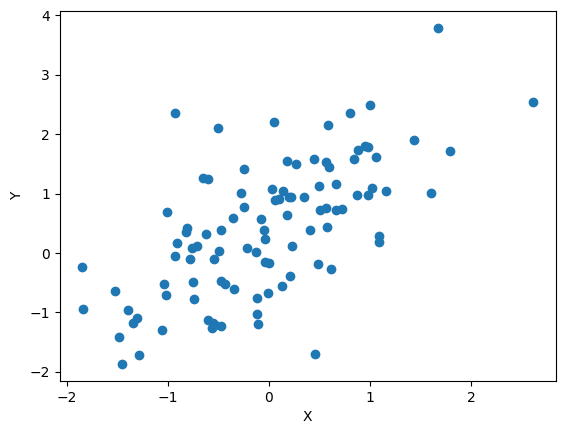

In [65]:
plt.scatter(X,Y)
plt.xlabel("X")
plt.ylabel("Y")

### Split dataset into train and test set

In [66]:
train_split = 0.8
train_idx = np.random.choice(np.arange(N), int(N*train_split), replace=False)
X_train = X[train_idx]
Y_train = Y[train_idx]

test_idx = torch.ones(N, dtype=torch.bool)
test_idx[train_idx]=False
X_test = X[test_idx]
Y_test = Y[test_idx]

In [67]:
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

(torch.Size([80]), torch.Size([80]), torch.Size([20]), torch.Size([20]))

In [68]:
def plot_data(X_train, Y_train, X_test, Y_test, figsize=[10,10], train_label="Train set", test_label="Test set", pred=False):
    plt.figure(figsize=figsize)
    plt.scatter(X_train, Y_train, c='blue', label=train_label)
    if pred:
        plt.plot(X_test, Y_test, c='green', label=test_label)
    else:
        plt.scatter(X_test, Y_test, c='green', label=test_label)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend(prop={"size": 14})
    plt.show()

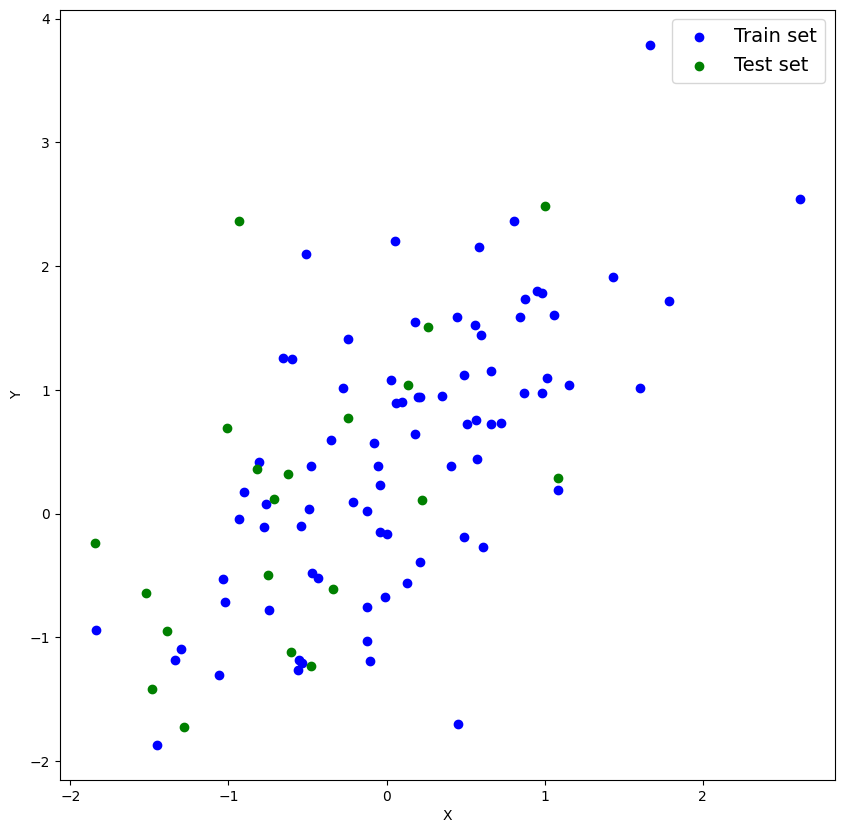

In [69]:
plot_data(X_train, Y_train, X_test, Y_test)

### Build a model

In [70]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weigth = nn.Parameter(torch.randn(
                1,
                dtype=torch.float
            ),
            requires_grad=True
        )

        self.bias = nn.Parameter(torch.randn(
                1,
                dtype=torch.float
            ),
            requires_grad=True
        )

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        return self.weigth*X+self.bias

In [71]:
torch.manual_seed(237)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([2.0883], requires_grad=True),
 Parameter containing:
 tensor([0.4275], requires_grad=True)]

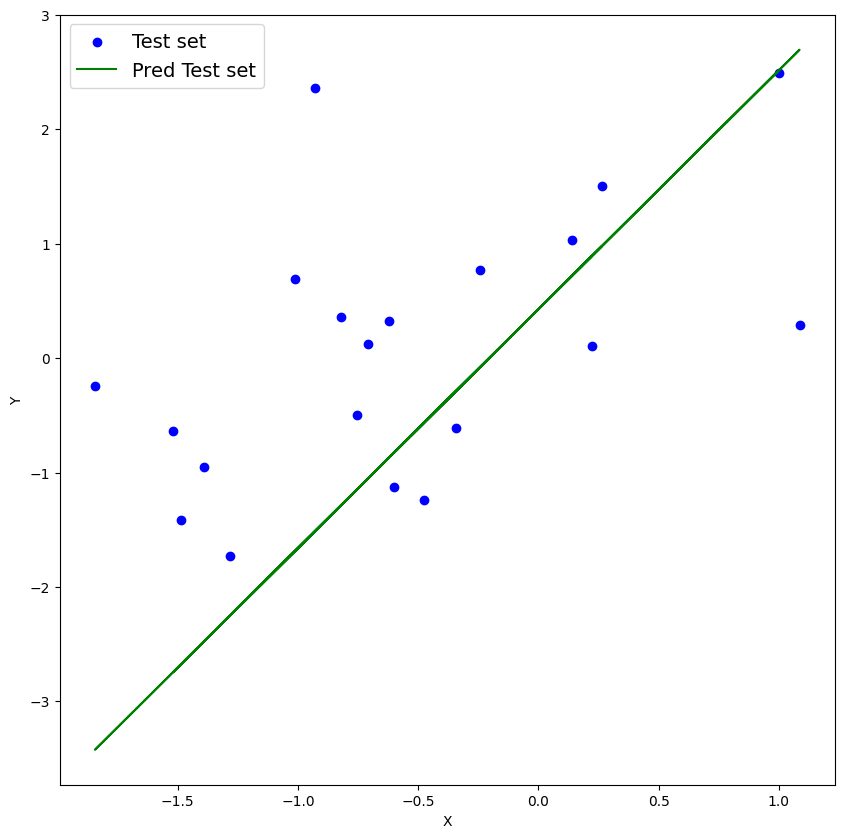

In [72]:
model_0.eval()

with torch.inference_mode(): 
    plot_data(X_test, Y_test, X_test, model_0(X_test).detach().numpy(), train_label="Test set", test_label="Pred Test set", pred=True)

### Train the model

In [73]:
learning_rate = 0.05
loss_func = nn.MSELoss()

optimizer = torch.optim.SGD(params=model_0.parameters(), 
                           lr=learning_rate)

In [74]:
epochs = 100
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    # Set model in train mode
    model_0.train()
    # Forward pass
    Y_hat = model_0(X_train)

    # Loss of prediction on train set
    train_loss = loss_func(Y_train, Y_hat)

    # Reset gradient to zero 
    optimizer.zero_grad()

    # Backward pass
    train_loss.backward()

    # Optimization
    optimizer.step()

    # Set model in evaluation mode 
    model_0.eval()

    with torch.inference_mode():
        y_pred = model_0(X_test)
        test_loss = loss_func(Y_test, y_pred)

        # Print out what's happening
        if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(train_loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MSE Train Loss: {train_loss} | MSE Test Loss: {test_loss} ")

Epoch: 0 | MSE Train Loss: 1.5955278873443604 | MSE Test Loss: 2.5096747875213623 
Epoch: 10 | MSE Train Loss: 0.9087213277816772 | MSE Test Loss: 1.5518065690994263 
Epoch: 20 | MSE Train Loss: 0.7395880222320557 | MSE Test Loss: 1.2157779932022095 
Epoch: 30 | MSE Train Loss: 0.6955751180648804 | MSE Test Loss: 1.0893713235855103 
Epoch: 40 | MSE Train Loss: 0.6838238835334778 | MSE Test Loss: 1.0376272201538086 
Epoch: 50 | MSE Train Loss: 0.6806506514549255 | MSE Test Loss: 1.0146420001983643 
Epoch: 60 | MSE Train Loss: 0.679789662361145 | MSE Test Loss: 1.003756046295166 
Epoch: 70 | MSE Train Loss: 0.6795557141304016 | MSE Test Loss: 0.9983758926391602 
Epoch: 80 | MSE Train Loss: 0.6794918775558472 | MSE Test Loss: 0.9956482648849487 
Epoch: 90 | MSE Train Loss: 0.6794746518135071 | MSE Test Loss: 0.994245707988739 


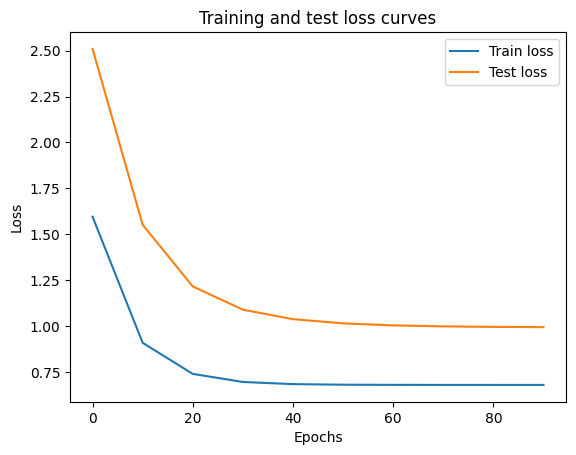

In [75]:
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

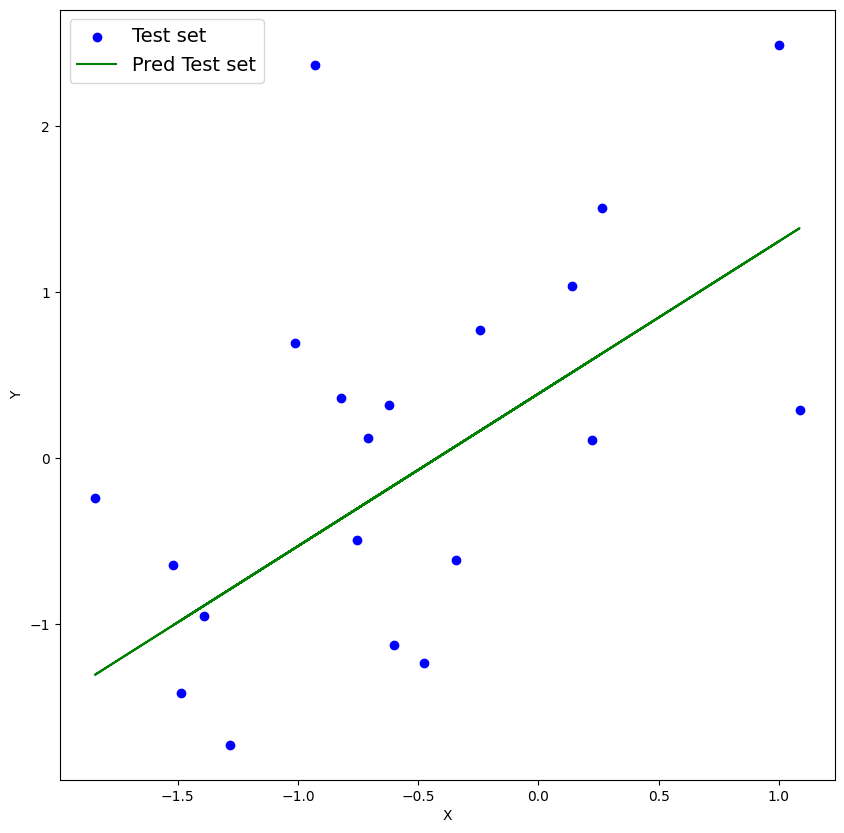

In [76]:
model_0.eval()

with torch.inference_mode(): 
    plot_data(X_test, Y_test, X_test, model_0(X_test).detach().numpy(), train_label="Test set", test_label="Pred Test set", pred=True)

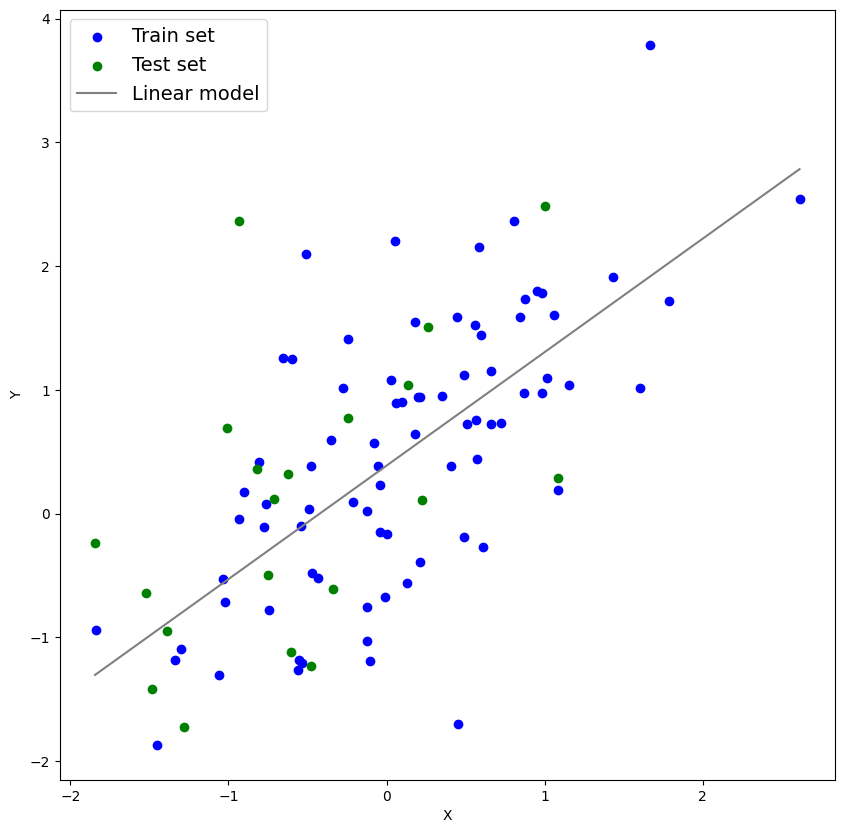

In [77]:
model_0.eval()

with torch.inference_mode():
    plt.figure(figsize=[10,10])
    plt.scatter(X_train, Y_train, c='blue', label='Train set')
    plt.scatter(X_test, Y_test, c='green', label='Test set')
    plt.plot(torch.sort(X).values.detach().numpy(), model_0(torch.sort(X).values).detach().numpy(), c='grey', label='Linear model')
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend(prop={"size": 14})
    plt.show()

In [78]:
print(f"Learning outcome : \nweigth = {float(model_0.state_dict()['weigth']):3f}, bias = {float(model_0.state_dict()['bias']):3f}")
print(f"Actual values of parameters : \nweight = {weight}, bias = {bias}")

Learning outcome : 
weigth = 0.917532, bias = 0.386910
Actual values of parameters : 
weight = 0.7, bias = 0.3
